# K-Nearest-Neighbors (KNN) Algorithm:
KNN is simple `supervise learning algorithm ` that can be used for both classification and regression problems. It works by finding the `k` nearest neighbors to a given data point and making predictions based on the majority class (for classification) or average value (for regression) of those neighbors.
## Steps to Implement KNN:
1. **Choose the number of neighbors (k)**: Decide how many nearest neighbors you want to consider for making predictions. A common choice is `k=3` or `k=5`, but it can be tuned based on the dataset.
2. **Calculate distances**: For a given data point, calculate the distance to all other data points in the training set. Common distance metrics include Euclidean distance, Manhattan distance, and Minkowski distance.
3. **Identify nearest neighbors**: Sort the distances and identify the `k` closest neighbors to the data point.
4. **Make predictions**:
   - For classification: Determine the majority class among the `k` neighbors and assign that class to the data point.
   - For regression: Calculate the average value of the `k` neighbors and assign that value to the data point.

In [27]:
# # example of KNN algorithm on iris datset using sns
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [28]:
# load the dataset
df = sns.load_dataset('iris')

In [29]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [30]:
x = df.drop('species', axis=1)
y = df['species']

In [31]:
# load and fit the KNN cllassifier
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(x, y)



,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [32]:
# train test split the data 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)                    


In [33]:
# evalute the model
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.90      0.90      0.90        10
   virginica       0.80      0.80      0.80         5

    accuracy                           0.93        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.93      0.93      0.93        30

[[15  0  0]
 [ 0  9  1]
 [ 0  1  4]]


Text(50.722222222222214, 0.5, 'Actual')

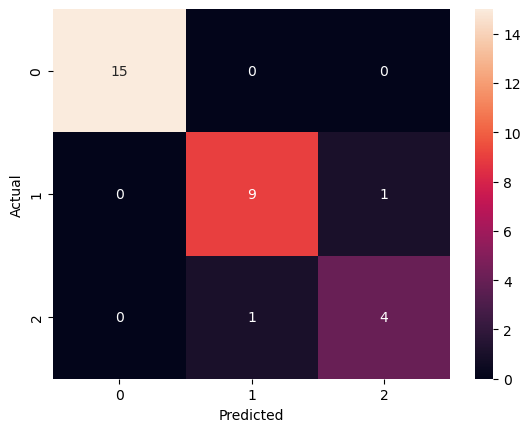

In [34]:
# plot the using heatmap
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')

# KNN ON REGRESSION PROBLEM:
In regression problems, KNN can be used to predict continuous values. The process is similar to classification, but instead of taking the majority class, you take the average of the `k` nearest neighbors' values to make a prediction.

In [35]:
# LOAD THE DATASET OF TIPS
tips = sns.load_dataset('tips') 
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [36]:
x = tips.drop('tip', axis=1)
y = tips['tip']

In [50]:
# encode the categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in x.columns:
    if x[col].dtype == 'object' or x[col].dtype.name == 'category':
        x[col] = le.fit_transform(x[col])

In [51]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [52]:
# split the data into train and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)


In [53]:
from sklearn.neighbors import KNeighborsRegressor
knn_reg = KNeighborsRegressor(n_neighbors=4)
knn_reg.fit(x_train, y_train)   
y_pred = knn_reg.predict(x_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))


0.8277551020408165
1.326676785714286
